In [1]:
import numpy as np  # for matrix operations
import pandas as pd # for data loading
import matplotlib.pyplot as plt  # for plotting
import seaborn as sns  # for plotting
sns.set_theme()

# Part 1

I will refer the feature matrix as `X` and dependent variable vector as `y` 

In [3]:
# Loading the data
training_data=pd.read_csv('FMLA1Q1Data_train.csv', header=None)
training_data.head()
X, y=training_data.drop(labels=2, axis=1), training_data[2]

Analyticial Solution is given by the below formula

$w_{ML}=(X^TX)^{-1}X^TY$

The `analytical_solution()` is the method that calculates the analytical solution.

In [96]:
def mse(y_true, y_pred):
    return np.sum((y_true-y_pred)**2)/y_true.shape[0]

class OLS:
    def fit(self, X, y):
        X_=X.copy()
        X_=np.concatenate((X, np.ones(shape=(X.shape[0], 1))), axis=1)
        self.coef_=(np.linalg.pinv(X_.T @ X_)) @ X_.T @ y

    def predict(self, X):
        X_=X.copy()
        X_=np.concatenate((X, np.ones(shape=(X.shape[0], 1))), axis=1)
        return X_ @ self.coef_

In [220]:
reg=OLS()
reg.fit(X, y)
w_ml=reg.coef_
w_ml, mse(y, reg.predict(X))

(array([1.76570568, 3.5215898 , 9.89400832]), 123.36485997994839)

In [136]:
class GradientDescent:
    def __init__(self, step_size=None, iterations=1000):
        self.step_size=step_size
        self.iterations=iterations
        self.coef_=None

    def gradient(self, X, y):
        return (X.T @ X @ self.coef_) - (X.T @ y)
    
    def fit(self, X, y):
        X_=X.copy()
        X_=np.concatenate((X, np.ones(shape=(X.shape[0], 1))), axis=1)
        self.coef_=np.random.normal(scale=0.1, size=X_.shape[1])
        self.errors=[]
        self.actual_iterations=0
        calc_step_size=lambda x: self.step_size
        if self.step_size is None:
            calc_step_size=lambda x: 1/(1+x) 
        for _ in range(self.iterations):
            grad=self.gradient(X_, y)
            if np.linalg.norm(grad)==0:
                break
            self.coef_-=calc_step_size(self.actual_iterations)*grad
            self.errors.append(np.linalg.norm(w_ml-self.coef_))
            self.actual_iterations+=1
        
    def predict(self, X):
        X_=X.copy()
        X_=np.concatenate((X, np.ones(shape=(X.shape[0], 1))), axis=1)
        return X_ @ self.coef_

In [137]:
gd=GradientDescent(step_size=0.0001, iterations=200)
gd.fit(X, y)
gd.coef_

array([1.76570567, 3.5215898 , 9.89400831])

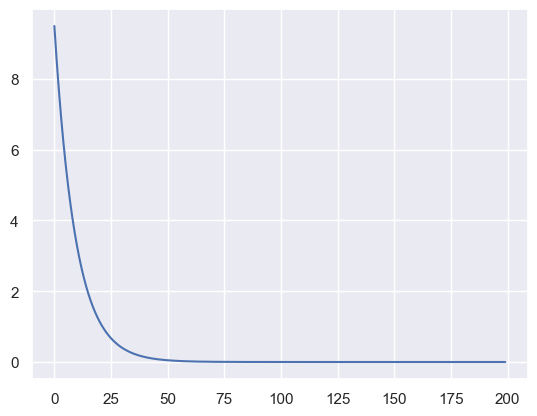

In [138]:
plt.plot(range(gd.actual_iterations), gd.errors)

In [139]:
class StochasticGradientDescent:
    def __init__(self, step_size=None, iterations=1000):
        self.step_size=step_size
        self.iterations=iterations
        self.coef_=None

    def gradient(self, X, y):
        return (X.T @ X @ self.coef_) - (X.T @ y)
    
    def fit(self, X, y):
        X_=X.copy()
        X_=np.concatenate((X, np.ones(shape=(X.shape[0], 1))), axis=1)
        self.coef_=np.random.normal(scale=0.1, size=X_.shape[1])
        self.errors=[]
        self.actual_iterations=0
        calc_step_size=lambda x: self.step_size
        rng=np.random.default_rng(seed=3)
        converged=False
        result=self.coef_.copy()
        index=np.arange(stop=X.shape[0])
        if self.step_size is None:
            calc_step_size=lambda x: 1/(1+x) 
        while (not converged) and (self.actual_iterations<self.iterations):
            rng.shuffle(index)
            factor=100
            while ((factor-100)<index.shape[0]) and (self.actual_iterations<self.iterations):
                X_temp, y_temp=X_[index[factor-100:factor], :], y[index[factor-100:factor]]
                grad=self.gradient(X_temp, y_temp)
                if np.linalg.norm(grad)==0:
                    converged=True
                    break
                self.coef_-=calc_step_size(self.actual_iterations)*grad
                result+=self.coef_
                self.errors.append(np.linalg.norm(w_ml-self.coef_))
                self.actual_iterations+=1
                factor+=100
        
        self.coef_=result/self.actual_iterations
        
    def predict(self, X):
        X_=X.copy()
        X_=np.concatenate((X, np.ones(shape=(X.shape[0], 1))), axis=1)
        return X_ @ self.coef_


In [149]:
sgd=StochasticGradientDescent(step_size=0.0025, iterations=1000)
sgd.fit(X, y)
sgd.coef_

array([1.7609418 , 3.51435964, 9.87902509])

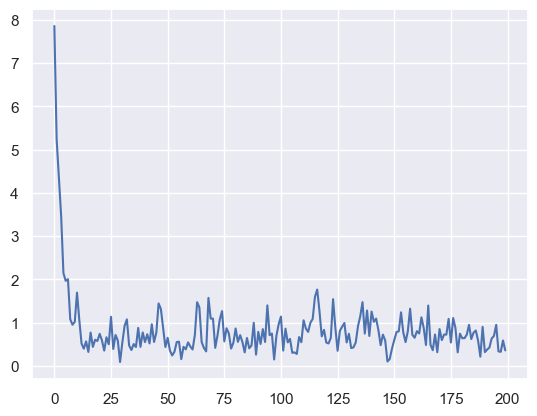

In [151]:
plt.plot(range(sgd.actual_iterations)[:200], sgd.errors[:200])

In [187]:
class RidgeGD:
    def __init__(self, regu, step_size=None, iterations=1000):
        self.regu=regu
        self.step_size=step_size
        self.iterations=iterations
        self.coef_=None

    def gradient(self, X, y):
        penalty=self.regu*self.coef_
        # penalty[:-1]=0
        return (X.T @ X @ self.coef_) - (X.T @ y) + penalty
    
    def fit(self, X, y):
        X_=X.copy()
        X_=np.concatenate((X, np.ones(shape=(X.shape[0], 1))), axis=1)
        self.coef_=np.random.normal(scale=0.1, size=X_.shape[1])
        self.errors=[]
        self.actual_iterations=0
        calc_step_size=lambda x: self.step_size
        if self.step_size is None:
            calc_step_size=lambda x: 1/(1+x) 
        for _ in range(self.iterations):
            grad=self.gradient(X_, y)
            if np.linalg.norm(grad)==0:
                break
            self.coef_-=calc_step_size(self.actual_iterations)*grad
            self.errors.append(np.linalg.norm(w_ml-self.coef_))
            self.actual_iterations+=1
        
    def predict(self, X):
        X_=X.copy()
        X_=np.concatenate((X, np.ones(shape=(X.shape[0], 1))), axis=1)
        return X_ @ self.coef_

In [190]:
rgd=RidgeGD(regu=15, step_size=0.0001, iterations=1000)
rgd.fit(X, y)
rgd.coef_, rgd.actual_iterations

(array([1.73438587, 3.47440013, 9.74850005]), 1000)

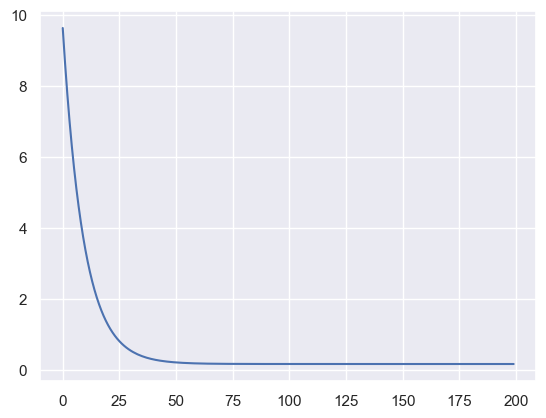

In [191]:
plt.plot(range(rgd.actual_iterations)[:200], rgd.errors[:200])

In [194]:
def genrate_splits(n, test_size):
   rng=np.random.default_rng(seed=3)
   index=np.arange(n)
   sorted_index=index.copy()
   rng.shuffle(index)
   factor=int(n*test_size)+1
   iterations=0
   while (factor*iterations < index.shape[0]):
      test_index=(sorted_index>=iterations*factor) & (sorted_index<(iterations+1)*factor)
      train_index=~test_index
      yield train_index, test_index
      iterations+=1
   


def cross_validate(X, y, model, test_size):
   iterations=0
   errors=0
   for train_index, validation_index in genrate_splits(X.shape[0], test_size):
      X_train, X_valid, y_train, y_valid=X.loc[train_index, :], X.loc[validation_index, :], y[train_index], y[validation_index]
      model.fit(X_train, y_train)
      predictions=model.predict(X_valid)
      errors+=mse(y_valid, predictions)
      iterations+=1

   return errors/iterations

In [200]:
cross_validate(X, y, RidgeGD(15, 0.0001, 1000), 0.2)

124.97971257400465

In [201]:
alphas = np.arange(0, 40, 1)
errors=[]
for alpha in alphas:
    errors.append(cross_validate(X, y, RidgeGD(alpha, 0.0001, 1000), 0.2))

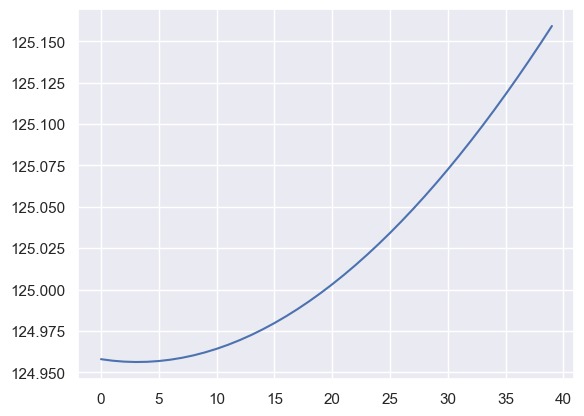

In [202]:
plt.plot(alphas, errors)

In [204]:
np.argmin(errors)

3

In [207]:
np.min(errors), errors[3], alphas[3]

(124.95618796478917, 124.95618796478917, 3)

In [209]:
testing_data=pd.read_csv('FMLA1Q1Data_test.csv', header=None)
X_test, y_test=testing_data.drop(labels=2, axis=1), testing_data[2]

In [211]:
reg=OLS()
reg.fit(X_test, y_test)

rgd=RidgeGD(regu=3, step_size=0.0001, iterations=1000)
rgd.fit(X_test, y_test)


predictions_ml=reg.predict(X_test)
error_ml=mse(y_test, predictions_ml)

predictions_ridge=rgd.predict(X_test)
error_ridge=mse(y_test, predictions_ridge)
print('Error ML : %1.3f'%error_ml)
print('Error Ridge : %1.3f'%error_ridge)

Error ML : 63.738
Error Ridge : 63.829


In [212]:
class KernelRegression:
    def __init__(self, degree):
        self.degree=degree
        self.data=None
        self.alpha=None
    
    def  calc_kernel(self, X_new):
        return ((X_new @ self.data.T) + 1)**self.degree



    def fit(self, X, y):
        self.data=X
        self.alpha=np.linalg.pinv(self.calc_kernel(self.data)) @ y
    
    def predict(self, X):
        return self.calc_kernel(X) @ self.alpha
        

In [234]:
kreg=KernelRegression(degree=2)
kreg.fit(X, y)

In [235]:
predictions=kreg.predict(X)
mse(y, predictions)

0.01006536308315977

In [232]:
degrees=np.array(range(1, 5))
errors=[]
for degree in degrees:
    errors.append(cross_validate(X, y, KernelRegression(degree), 0.2))

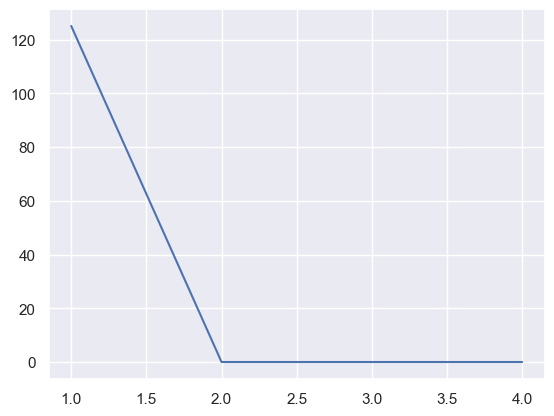

In [233]:
plt.plot(degrees, errors)

In [236]:
predictions=kreg.predict(X_test)
mse(y_test, predictions)

0.009798525084448683